# Data Exploration

## Configurações Iniciais

### Configurações a depender do ambiente

In [37]:
import os
import sys
import subprocess

# --- CONFIGURAÇÃO ALVO ---
TARGET_PYSPARK = "4.1.1"

# 1. Identifica o Ambiente (Fora da função para ser global)
IN_COLAB = 'google.colab' in sys.modules
ENV_NAME = "☁️ Google Colab" if IN_COLAB else "💻 Ambiente Local (WSL/Jupyter)"

print(f"Detectado: {ENV_NAME}")
print(f"Versão do Python: {sys.version.split()[0]}")

# 2. Define os Caminhos Globais
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/1_bronze_data/"
    SAVE_PATH = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/2_silver_data/"
else:
    BASE_PATH = "../1_bronze_data/"
    SAVE_PATH = "../2_silver_data/"
def setup_pyspark():
    if IN_COLAB:
        try:
            import pyspark
            if pyspark.__version__ != TARGET_PYSPARK:
                print(f"(!) Atualizando PySpark de {pyspark.__version__} para {TARGET_PYSPARK}...")
                subprocess.check_call([sys.executable, "-m", "pip", "install", f"pyspark=={TARGET_PYSPARK}", "-q"])
                print("🚨 Reinicie o Ambiente (Runtime > Restart Session) para aplicar a mudança!")
        except ImportError:
            print(f"(!) Instalando PySpark {TARGET_PYSPARK}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", f"pyspark=={TARGET_PYSPARK}", "-q"])

    # Verificação Final
    try:
        import pyspark
        if pyspark.__version__ == TARGET_PYSPARK:
            print(f"✅ PySpark {pyspark.__version__} pronto!")
        else:
            print(f"⚠️ Alerta: PySpark está na versão {pyspark.__version__}. Alvo era {TARGET_PYSPARK}.")
    except ImportError:
        print("❌ Erro: PySpark não encontrado.")

setup_pyspark()

Detectado: ☁️ Google Colab
Versão do Python: 3.12.13
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(!) Atualizando PySpark de 4.0.2 para 4.1.1...
🚨 Reinicie o Ambiente (Runtime > Restart Session) para aplicar a mudança!
⚠️ Alerta: PySpark está na versão 4.0.2. Alvo era 4.1.1.


### Importação de Bibliotecas

In [38]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import DataFrame
from pyspark.sql.types import * # Para definir Schemas (StructType, DoubleType, etc)
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt

### Inicialização da Sessão Spark

In [39]:
spark = SparkSession.builder \
    .appName("DataExploration") \
    .master("local[*]") \
    .getOrCreate()

In [40]:
spark

### Importação de Dados

In [41]:
df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("delimiter", ";") \
    .option("encoding", "ISO-8859-1") \
    .load(f"{BASE_PATH}/b_incidentes.csv")

In [42]:
df.show(20)

+----------+----------+-------+---------+------------+---------------+--------------------+-------------------+---------+-------------------+-------+--------------------+-------+-------------+-------------+---------------+----------------+------------+-------------------+-------------------------+-----------------------+------------------------+---------------+
|    Número|Prioridade|Produto|Categoria|Subcategoria|Grupo designado|Item de configuração|             Aberto|Resolvido|          Encerrado|Duração|  Descrição Resumida|Solução|   Aberto por|Incidente Pai|         Status|Entrou para KPI?|KPI Violado?|Tempo_Pos_Resolução|Resolvido_after_Encerrado|Duração_is_inconsistent|Diferença_Limite_Duração|Modified_Record|
+----------+----------+-------+---------+------------+---------------+--------------------+-------------------+---------+-------------------+-------+--------------------+-------+-------------+-------------+---------------+----------------+------------+-------------------+

In [43]:
df.printSchema()

root
 |-- Número: string (nullable = true)
 |-- Prioridade: string (nullable = true)
 |-- Produto: string (nullable = true)
 |-- Categoria: string (nullable = true)
 |-- Subcategoria: string (nullable = true)
 |-- Grupo designado: string (nullable = true)
 |-- Item de configuração: string (nullable = true)
 |-- Aberto: timestamp (nullable = true)
 |-- Resolvido: timestamp (nullable = true)
 |-- Encerrado: timestamp (nullable = true)
 |-- Duração: integer (nullable = true)
 |-- Descrição Resumida: string (nullable = true)
 |-- Solução: string (nullable = true)
 |-- Aberto por: string (nullable = true)
 |-- Incidente Pai: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Entrou para KPI?: string (nullable = true)
 |-- KPI Violado?: string (nullable = true)
 |-- Tempo_Pos_Resolução: integer (nullable = true)
 |-- Resolvido_after_Encerrado: boolean (nullable = true)
 |-- Duração_is_inconsistent: boolean (nullable = true)
 |-- Diferença_Limite_Duração: integer (nullable = 

In [44]:
# Tamanho df
total_registros = df.count()
colunas_originais = df.columns
numero_colunas = len(colunas_originais)
print(f"Total de Registros: {total_registros}")
print(f"Total de Colunas: {numero_colunas}")

Total de Registros: 122543
Total de Colunas: 23


## Exploração de Dados

### Sobre o DF

In [45]:
coluna_chave = "Número"

colunas_categoricas = [
    "Prioridade",
    "Produto",
    "Categoria",
    "Subcategoria",
    "Grupo designado",
    "Item de configuração",
    "Descrição Resumida",
    "Solução",
    "Aberto por",
    "Status",
    "Incidente Pai"
]

colunas_numericas = [
    "Duração", # Duração em segundos do incidente
    "Tempo_Pos_Resolução", # Tempo entre Resolvido e Encerrado
    "Diferença_Limite_Duração" # Quanto a duração extrapolou o limite OLA
]

colunas_temporais = [
    "Aberto",
    "Resolvido",
    "Encerrado",
]

colunas_validacao = [
    "Duração_is_inconsistent",
    "Modified_Record",
    "Resolvido_after_Encerrado",
    "Entrou para KPI?",
    "KPI Violado?"
]

total_colCat = len(colunas_categoricas)
total_colNum = len(colunas_numericas)
total_colTemp = len(colunas_temporais)
total_colVal = len(colunas_validacao)
total_col = total_colCat + total_colNum + total_colTemp + total_colVal + 1
if total_col == numero_colunas:
  print(f"Total de Colunas: {total_col}")
  print(f"Total de Colunas Numéricas: {total_colNum}")
  print(f"Total de Colunas Temporais: {total_colTemp}")
  print(f"Total de Colunas de Validação: {total_colVal}")
  print(f"Total de Colunas Categóricas: {total_colCat}")
else:
  print(f"Faltam classificar colunas {numero_colunas - total_col}, revise.")


Total de Colunas: 23
Total de Colunas Numéricas: 3
Total de Colunas Temporais: 3
Total de Colunas de Validação: 5
Total de Colunas Categóricas: 11


### Período Temporal

In [46]:
data_minima_Aberto = df.agg(F.min("Aberto")).first()[0]
data_maxima_Aberto = df.agg(F.max("Aberto")).first()[0]
data_minima_Resolvido = df.agg(F.min("Resolvido")).first()[0]
data_maxima_Resolvido = df.agg(F.max("Resolvido")).first()[0]
data_minima_Encerrado = df.agg(F.min("Encerrado")).first()[0]
data_maxima_Encerrado = df.agg(F.max("Encerrado")).first()[0]
data_minima = min(data_minima_Aberto, data_minima_Resolvido, data_minima_Encerrado)
data_maxima = max(data_maxima_Aberto, data_maxima_Resolvido, data_maxima_Encerrado)
intervalo_total = (data_maxima - data_minima).days
print(f"Data Mínima: {data_minima}")
print(f"Data Máxima: {data_maxima}")
print(f"Intervalo Total: {intervalo_total} dias")

Data Mínima: 2023-01-02 20:19:58
Data Máxima: 2025-12-31 23:45:32
Intervalo Total: 1094 dias


### Dados categóricos



In [11]:
freq_dict = {}

for col in colunas_categoricas:
    freq_dict[col] = df.groupBy(col) \
                          .count() \
                          .withColumn("percentual", F.round((F.col("count") / total_registros) * 100, 2)) \
                          .orderBy(F.desc("count"))

print(f"Frequencia por valor gerados para as colunas: {list(freq_dict.keys())}")

Frequencia por valor gerados para as colunas: ['Prioridade', 'Produto', 'Categoria', 'Subcategoria', 'Grupo designado', 'Item de configuração', 'Descrição Resumida', 'Solução', 'Aberto por', 'Status', 'Incidente Pai']


In [12]:
stats_data = []

for col_name in colunas_categoricas:
    metrics = df.select(
        F.count(F.col(col_name)).alias("non_nulls"),
        F.countDistinct(F.col(col_name)).alias("distincts"),
        F.sum(F.col(col_name).isNull().cast("int")).alias("nulls")
    ).collect()[0]

    nulls_count = metrics["nulls"]
    pct_nulls = (nulls_count / total_registros * 100) if total_registros > 0 else 0.0

    stats_data.append((
        col_name,
        total_registros,
        metrics["distincts"],
        metrics["nulls"],
        round(pct_nulls, 2)
    ))

df_info_cat = spark.createDataFrame(
    stats_data,
    ["coluna", "total_registros", "distintos", "nulos", "pct_nulls"]
)

df_info_cat.orderBy(F.asc("nulos"), F.asc("distintos")).show()

+--------------------+---------------+---------+------+---------+
|              coluna|total_registros|distintos| nulos|pct_nulls|
+--------------------+---------------+---------+------+---------+
|          Aberto por|         122543|        2|     0|      0.0|
|              Status|         122543|        4|     0|      0.0|
|          Prioridade|         122543|        5|     0|      0.0|
|     Grupo designado|         122543|       17|     0|      0.0|
|  Descrição Resumida|         122543|    17787|     0|      0.0|
|Item de configuração|         122543|     9171|  1780|     1.45|
|           Categoria|         122543|      141| 77719|    63.42|
|        Subcategoria|         122543|      447| 77720|    63.42|
|             Produto|         122543|       51| 77935|     63.6|
|             Solução|         122543|        2|107243|    87.51|
|       Incidente Pai|         122543|     3326|107419|    87.66|
+--------------------+---------------+---------+------+---------+



In [13]:
freq_dict['Aberto por'].show()

+-------------+------+----------+
|   Aberto por| count|percentual|
+-------------+------+----------+
|Monitoramento|104299|     85.11|
|       Manual| 18244|     14.89|
+-------------+------+----------+



In [14]:
freq_dict['Prioridade'].show()

+---------------+-----+----------+
|     Prioridade|count|percentual|
+---------------+-----+----------+
|      4 - Baixa|64828|      52.9|
|      3 - Média|41732|     34.05|
|       2 - Alta|15649|     12.77|
|5 - Muito Baixa|  333|      0.27|
|    1 - Crítica|    1|       0.0|
+---------------+-----+----------+



In [15]:
freq_dict['Status'].show()

+--------------------+-----+----------+
|              Status|count|percentual|
+--------------------+-----+----------+
|     Sem Intervenção|80373|     65.59|
|Encerrado Automat...|26830|     21.89|
|           Encerrado|15339|     12.52|
| Aguardando Problema|    1|       0.0|
+--------------------+-----+----------+



In [16]:
freq_dict['Grupo designado'].show()

+---------------+-----+----------+
|Grupo designado|count|percentual|
+---------------+-----+----------+
|         Team14|92775|     75.71|
|         Team11| 9790|      7.99|
|         Team05| 9276|      7.57|
|         Team09| 3425|      2.79|
|         Team12| 2173|      1.77|
|         Team03| 1306|      1.07|
|         Team10| 1172|      0.96|
|         Team17|  743|      0.61|
|         Team02|  579|      0.47|
|         Team01|  306|      0.25|
|         Team16|  279|      0.23|
|         Team15|  219|      0.18|
|         Team07|  197|      0.16|
|         Team08|  130|      0.11|
|         Team04|  122|       0.1|
|         Team06|   50|      0.04|
|         Team13|    1|       0.0|
+---------------+-----+----------+



*Informações gerais*

- A maior parte dos incidentes são P4,seguidos por P3 E P2. As classes minoritárias são P5 e P1 - com menos de 1% de representatividade na base. Inclusive, no período analisado, só teve 1 P1.

- Não há muitos incidentes abertos de forma manual, isso é um bom indicador. Precisamos entender por que e o que faz um incidente ser aberto manualmente.

- A maior parte dos incidentes são encerrados automaticamente ou não tem intervenção.

- A esmagadora maioria dos incidentes é resolvida pelo Time 14.

#### Prioridade

O que faz um incidente ser prioridade 1 - 5 ?

Objetivo da análise:
Ter clareza do que determina a prioridade de um incidente.

In [17]:
# nova coluna prioridade ordinal
df = df.withColumn(
    "Prioridade_Ordinal",
    F.when(F.col("Prioridade") == "1 - Crítica", 1)
    .when(F.col("Prioridade") == "2 - Alta", 2)
    .when(F.col("Prioridade") == "3 - Média", 3)
    .when(F.col("Prioridade") == "4 - Baixa", 4)
    .when(F.col("Prioridade") == "5 - Muito Baixa", 5)
)

In [18]:
# O incidente único P1
p1 = df.filter(F.col("Prioridade") == "1 - Crítica")
p1.show(truncate=False)

+----------+-----------+-------+---------+------------+---------------+--------------------+-------------------+-------------------+-------------------+-------+----------------------------------------------------------------------------------------------------+-------+-------------+-------------+---------+----------------+------------+-------------------+-------------------------+-----------------------+------------------------+---------------+------------------+
|Número    |Prioridade |Produto|Categoria|Subcategoria|Grupo designado|Item de configuração|Aberto             |Resolvido          |Encerrado          |Duração|Descrição Resumida                                                                                  |Solução|Aberto por   |Incidente Pai|Status   |Entrou para KPI?|KPI Violado?|Tempo_Pos_Resolução|Resolvido_after_Encerrado|Duração_is_inconsistent|Diferença_Limite_Duração|Modified_Record|Prioridade_Ordinal|
+----------+-----------+-------+---------+------------+---------

In [ ]:
# Tiveram outros incidentes no mesmo ic, produto categoria e sub

#### Incidente Pai

Essa coluna revela correlações e padrões de escalonamento de incidentes. O que faz um incidente gerar outros incidentes?

Objetivos da análise:
- Identificar padrões entre incidentes relacionados

In [24]:
# Criando Colunas auxiliares: Número de Filhos e Eh_Pai
df_contagem_filhos = df.filter(F.col("Incidente Pai").isNotNull()) \
    .groupBy("Incidente Pai") \
    .agg(F.count("Número").alias("Total_Filhos"))\
    .withColumnRenamed("Incidente Pai", "ID_Pai_Referencia")

df = df.join(
    df_contagem_filhos,
    df["Número"] == df_contagem_filhos["ID_Pai_Referencia"],
    "left"
)

df = df.withColumn(
    "Eh_Pai",
    F.when(F.col("Total_Filhos") > 0, True).otherwise(False)
).withColumn(
    "Total_Filhos",
    F.coalesce(F.col("Total_Filhos"), F.lit(0))
)

df = df.drop("ID_Pai_Referencia")

In [27]:
# Validando se existem incidentes pais com mais de 1 filho
df.filter(F.col("Eh_Pai") == True).select("Total_Filhos").summary().show()

+-------+------------------+
|summary|      Total_Filhos|
+-------+------------------+
|  count|              3065|
|   mean|  4.48515497553018|
| stddev|17.950246499607356|
|    min|                 1|
|    25%|                 1|
|    50%|                 1|
|    75%|                 3|
|    max|               630|
+-------+------------------+



In [30]:
# Validando se existem incidentes pais que também são filhos
df.filter(F.col("Eh_Pai") == True).filter(F.col("Incidente Pai").isNotNull()).count()

21

In [ ]:
# Explorando a hierarquia dos incidentes encadeados


#### Grupo designado

É a forma como a locaweb divide a solução dos incidentes - revela similaridades ocultas entre os incidentes.

Objetivos da análise:

- Descobrir o que cada time é responsável e quais características são mais importantes para o incidente ser direcionado a ele.

- Categorizar os times em níveis - de 1 a 3. Assim, podemos fazer one hot encoding para os modelos.

- Mensurar o comprimento de OLA de cada time ao longo do tempo.



In [ ]:
window_spec = Window.partitionBy("Grupo designado", "Prioridade_Ordinal")
window_rank = Window.partitionBy("Grupo designado").orderBy(F.desc("contagem_prioridade"))

df_moda_p_times = df.withColumn("contagem_prioridade", F.count("*").over(window_spec)) \
            .withColumn("rank", F.row_number().over(window_rank)) \
            .filter(F.col("rank") == 1) \
            .select("Grupo designado", F.col("Prioridade_Ordinal").alias("Moda_Prioridade"))

df_resumo_times = df.groupBy("Grupo designado").agg(
    F.count("*").alias("Total_Incidentes"),
    # Distribuição de Incidentes no time
    F.round((F.count(F.when(F.col("Prioridade_Ordinal") == 1, True)) / F.count("*")) * 100, 2).alias("Pct_P1"),
    F.round((F.count(F.when(F.col("Prioridade_Ordinal") == 2, True)) / F.count("*")) * 100, 2).alias("Pct_P2"),
    F.round((F.count(F.when(F.col("Prioridade_Ordinal") == 3, True)) / F.count("*")) * 100, 2).alias("Pct_P3"),
    F.round((F.count(F.when(F.col("Prioridade_Ordinal") == 4, True)) / F.count("*")) * 100, 2).alias("Pct_P4"),
    F.round((F.count(F.when(F.col("Prioridade_Ordinal") == 5, True)) / F.count("*")) * 100, 2).alias("Pct_P5"),
    # Total de incidentes de cada prioridade resolvido pelo time em relação ao total
    F.round((F.count(F.when(F.col("Prioridade_Ordinal") == 1, True)) / total_registros) * 100, 2).alias("Pct_P1_Total"),
    F.round((F.count(F.when(F.col("Prioridade_Ordinal") == 2, True)) / total_registros) * 100, 2).alias("Pct_P2_Total"),
    F.round((F.count(F.when(F.col("Prioridade_Ordinal") == 3, True)) / total_registros) * 100, 2).alias("Pct_P3_Total"),
    F.round((F.count(F.when(F.col("Prioridade_Ordinal") == 4, True)) / total_registros) * 100, 2).alias("Pct_P4_Total"),
    F.round((F.count(F.when(F.col("Prioridade_Ordinal") == 5, True)) / total_registros) * 100, 2).alias("Pct_P5_Total"),
    F.round((F.count(F.when(F.col("Aberto por") == "Manual", True)) / total_registros) * 100, 2).alias("Pct_Manual"),
    F.countDistinct("Produto").alias("Produtos_Dis"),
    F.countDistinct("Categoria").alias("Categorias_Dis"),
    F.countDistinct("Item de configuração").alias("Itens_Configuracao_Dis")
)

df_times = df_resumo_times.join(df_moda_p_times, on="Grupo designado", how="left")

df_times = df_times.withColumn(
    "Inc_por_Produto",
    F.round(F.col("Total_Incidentes") / F.col("Produtos_Dis"), 2)
)

df_times = df_times.withColumn(
    "Inc_por_Categoria",
    F.round(F.col("Total_Incidentes") / F.col("Categorias_Dis"), 2)
)

df_times = df_times.withColumn(
    "Inc_por_Item_Configuracao",
    F.round(F.col("Total_Incidentes") / F.col("Itens_Configuracao_Dis"), 2)
)

df_times.orderBy(F.desc("Total_Incidentes")).show()

+---------------+----------------+------+------+------+------+------+------------+------------+------------+------------+------------+----------+------------+--------------+----------------------+---------------+---------------+-----------------+-------------------------+
|Grupo designado|Total_Incidentes|Pct_P1|Pct_P2|Pct_P3|Pct_P4|Pct_P5|Pct_P1_Total|Pct_P2_Total|Pct_P3_Total|Pct_P4_Total|Pct_P5_Total|Pct_Manual|Produtos_Dis|Categorias_Dis|Itens_Configuracao_Dis|Moda_Prioridade|Inc_por_Produto|Inc_por_Categoria|Inc_por_Item_Configuracao|
+---------------+----------------+------+------+------+------+------+------------+------------+------------+------------+------------+----------+------------+--------------+----------------------+---------------+---------------+-----------------+-------------------------+
|         Team14|           92775|   0.0| 11.07| 22.88| 65.79|  0.27|         0.0|        8.38|       17.32|       49.81|         0.2|      3.38|          29|            73|        

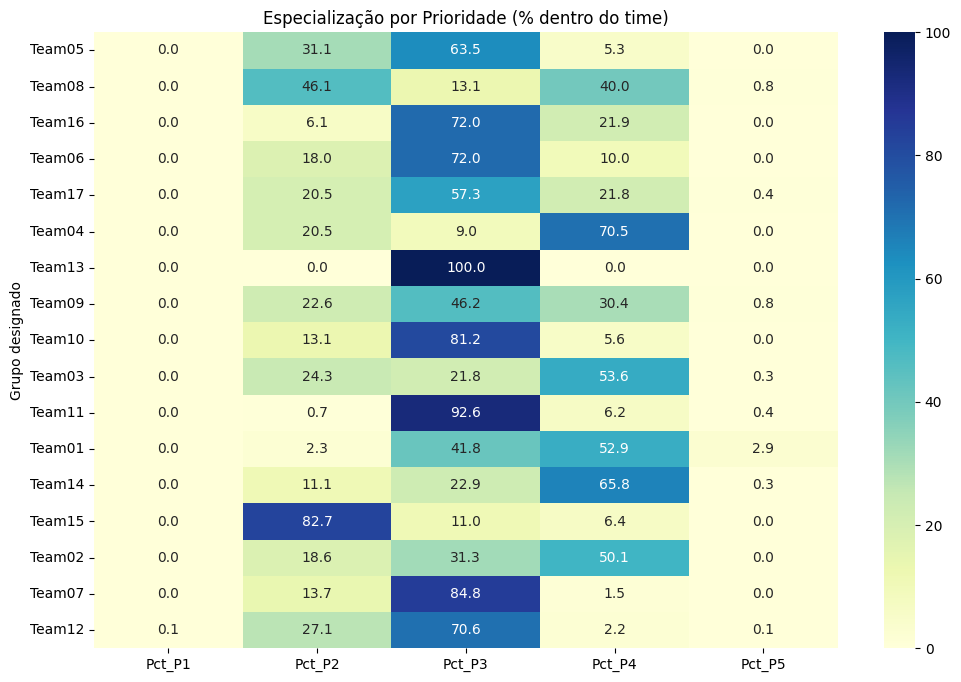

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Converte para Pandas (apenas o resultado final, que é pequeno)
pdf = df_times.toPandas().set_index("Grupo designado")

# Filtra apenas as colunas de Pct dentro do time para o Heatmap
pct_cols = ["Pct_P1", "Pct_P2", "Pct_P3", "Pct_P4", "Pct_P5"]

plt.figure(figsize=(12, 8))
sns.heatmap(pdf[pct_cols], annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Especialização por Prioridade (% dentro do time)")
plt.show()

In [ ]:
# Definição do nível das equipes

### Incidentes por dia

In [ ]:
df = df.withColumn("Data", F.to_date("Aberto"))
df_diario = df.groupby("Data").agg(
    # Coluna Número
    F.count("*").alias("Total_Incidentes"),
    # Coluna Prioridade
    F.count(F.when(F.col("Prioridade") == "1 - Crítica", True)).alias("P1"),
    F.count(F.when(F.col("Prioridade") == "2 - Alta", True)).alias("P2"),
    F.count(F.when(F.col("Prioridade") == "3 - Média", True)).alias("P3"),
    F.count(F.when(F.col("Prioridade") == "4 - Baixa", True)).alias("P4"),
    F.count(F.when(F.col("Prioridade") == "5 - Muito Baixa", True)).alias("P5"),
    # Coluna Produto
    F.count(F.when(F.col("Produto").isNotNull(), True)).alias("Possui_Produto"),
    # Coluna Categoria e Subcategoria - a explorar métricas possíveis
    # Coluna Grupo Designado - a explorar métricas possíveis
    # Coluna Item de configuração - a explorar métricas possíveis
    F.count(F.when(F.col("Item de configuração").isNotNull(), True)).alias("Possui_Item_Configuracao"),
    # Coluna Resolvido
    F.count(F.when(F.col("Resolvido").isNotNull(), True)).alias("Possui_Resolvido"),
    # Coluna Encerrado
    F.count(F.when(F.datediff(F.to_date("Encerrado"), F.to_date("Aberto")) == 0, True)).alias("Encerrados no Mesmo Dia"),
    # Coluna Duração
    F.avg(F.col("Duração")).alias("Duração_Média"),
    # Coluna Código de fechamento - a explorar métricas possíveis
    # Coluna Descrição resumida - a explorar métricas possíveis
    # Coluna Solução
    F.count(F.when(F.col("Solução").isNotNull(), True)).alias("Possui_Solução"),
    F.count(F.when(F.col("Solução") == "Contorno", True)).alias("Solução_Contorno"),
    F.count(F.when(F.col("Solução") == "Definitiva", True)).alias("Solução_Definitiva"),
    # Coluna Aberto por
    F.count(F.when(F.col("Aberto por") == "Manual", True)).alias("Aberto_Manual"),
    F.count(F.when(F.col("Aberto por") == "Monitoramento", True)).alias("Aberto_Monitoramento"),
    # Coluna Incidente Pai
    F.count(F.when(F.col("Incidente Pai").isNotNull(), True)).alias("Possui_Incidente_Pai"),
    # Coluna Status
    F.count(F.when(F.col("Status") == "Encerrado", True)).alias("Encerrado"),
    F.count(F.when(F.col("Status") == "Encerrado Automaticamente", True)).alias("Encerrado_Automaticamente"),
    F.count(F.when(F.col("Status") == "Sem Intervenção", True)).alias("Sem Intervenção"),
    # Entrou para KPI?
    F.count(F.when(F.col("Entrou para KPI?") == "SIM", True)).alias("Entrou_KPI"),
    # KPI Violado?
    F.count(F.when(F.col("KPI Violado?") == "SIM", True)).alias("KPI_Violado"),
    # Coluna Tempo_Pos_Resolução
    F.avg(F.col("Tempo_Pos_Resolução").alias("Tempo_Pos_Resolução_Médio"))
).orderBy("Data")

In [ ]:
df_diario.count() == intervalo_total

False

In [ ]:
df_diario.count() - intervalo_total

-450

In [ ]:
df_datas = spark.createDataFrame(
    [(data_minima, data_maxima)],
    ["start", "end"]
).select(
    F.explode(
        F.sequence(
            F.to_date("start"),
            F.to_date("end")
        )
    ).alias("Data")
)
df_diario.select("Data").printSchema()
df_datas.select("Data").printSchema()
df_diario = df_datas.join(df_diario, on="Data", how="left")
df_diario = df_diario.fillna(0)
df_diario = df_diario.withColumn(
    "tem_incidente",
    F.when(F.col("Total_Incidentes") > 0, 1).otherwise(0)
)

root
 |-- Data: date (nullable = true)

root
 |-- Data: date (nullable = false)



In [ ]:
df_diario.count() - intervalo_total - 1

0

In [ ]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"


pdf = df_diario.select("Data", "Total_Incidentes")\
    .orderBy("Data")\
    .toPandas()

fig = px.line(
    pdf,
    x="Data",
    y="Total_Incidentes",
    title="Total de Incidentes por Dia",
    markers=True
)

fig.update_layout(
    xaxis_title="Data",
    yaxis_title="Quantidade de Incidentes",
    hovermode="x unified"
)

fig.show()

gio: http://127.0.0.1:45443: Operation not supported
